In [1]:
cd ~/Documents/diarka-qaoa-portfolio

/Users/hp/Documents/diarka-qaoa-portfolio


In [2]:
conda activate qiskit-env


CondaError: Run 'conda init' before 'conda activate'


Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [4]:
import qiskit
print(qiskit.__version__)

2.3.1


In [5]:
pip install qiskit-ibm-runtime

  Using cached qiskit_ibm_runtime-0.47.0-py3-none-any.whl.metadata (23 kB)
  Using cached requests_ntlm-1.3.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached ibm_platform_services-0.75.0-py3-none-any.whl.metadata (9.2 kB)
  Using cached ibm_quantum_schemas-0.7.20260419-py3-none-any.whl.metadata (3.0 kB)
  Using cached pybase64-1.4.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.7 kB)
  Using cached samplomatic-0.19.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached ibm_cloud_sdk_core-3.24.4-py3-none-any.whl.metadata (8.7 kB)
  Using cached pyjwt-2.13.0-py3-none-any.whl.metadata (3.4 kB)
  Using cached pyspnego-0.12.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached orjson-3.11.9-cp313-cp313-macosx_15_0_arm64.whl.metadata (41 kB)
Using cached qiskit_ibm_runtime-0.47.0-py3-none-any.whl (1.9 MB)
Using cached ibm_quantum_schemas-0.7.20260419-py3-none-any.whl (102 kB)
Using cached ibm_platform_services-0.75.0-py3-none-any.whl (386 kB)
Using cached ibm_cloud_sdk_core-3.24.4-py3-none-any.

In [6]:
pip install jupyter

  Using cached fqdn-1.5.1-py3-none-any.whl.metadata (1.4 kB)
  Using cached isoduration-20.11.0-py3-none-any.whl.metadata (5.7 kB)
  Using cached rfc3987_syntax-1.1.0-py3-none-any.whl.metadata (7.7 kB)
  Using cached uri_template-1.3.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached webcolors-25.10.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached lark-1.3.1-py3-none-any.whl.metadata (1.8 kB)
Using cached rfc3987_syntax-1.1.0-py3-none-any.whl (8.0 kB)
Using cached lark-1.3.1-py3-none-any.whl (113 kB)
Using cached webcolors-25.10.0-py3-none-any.whl (14 kB)
Using cached fqdn-1.5.1-py3-none-any.whl (9.1 kB)
Using cached isoduration-20.11.0-py3-none-any.whl (11 kB)
Using cached uri_template-1.3.0-py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [isoduration]
Note: you may need to restart the kernel to use updated packages.


In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token="<Ok-5Wi4WhXLeicq5d1QE-fU9lRQs-scpPSCavDE1HdtM>", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
)

AccountAlreadyExistsError: 'Named account (default-ibm-quantum-platform) already exists. Set overwrite=True to overwrite.'

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Run every time you need the service
service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-05-25 19:20:33,805: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


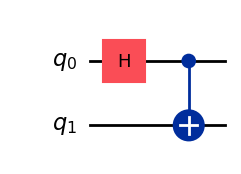

In [9]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorOptions
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from matplotlib import pyplot as plt
# Uncomment the next line if you want to use a simulator:
# from qiskit_ibm_runtime.fake_provider import FakeBelemV2


# Create a new circuit with two qubits
qc = QuantumCircuit(2)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)

# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

In [19]:
# Set up six different observables.

observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]
observables = [SparsePauliOp(label) for label in observables_labels]

qiskit_runtime_service.__init__:WARNING:2026-05-25 19:22:56,458: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-25 19:22:57,780: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-25 19:23:00,236: Using instance: open-instance, plan: open


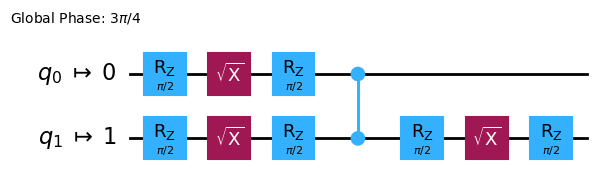

In [11]:
service = QiskitRuntimeService()

backend = service.least_busy(simulator=False, operational=True)

# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

isa_circuit.draw("mpl", idle_wires=False)

In [12]:
# Construct the Estimator instance.

estimator = Estimator(mode=backend)
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000

mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observables)])

# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d8a97bop0eas73dpioa0


In [13]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()

# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]

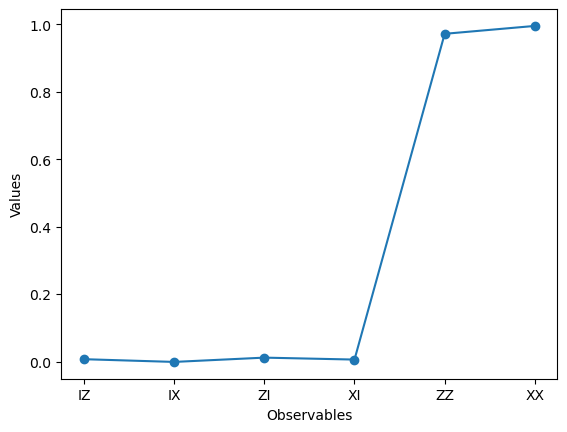

In [14]:
# Plot the result

values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

In [15]:
def get_qc_for_n_qubit_GHZ_state(n: int) -> QuantumCircuit:
    """This function will create a qiskit.QuantumCircuit (qc) for an n-qubit GHZ state.

    Args:
        n (int): Number of qubits in the n-qubit GHZ state

    Returns:
        QuantumCircuit: Quantum circuit that generate the n-qubit GHZ state, assuming all qubits start in the 0 state
    """
    if isinstance(n, int) and n >= 2:
        qc = QuantumCircuit(n)
        qc.h(0)
        for i in range(n - 1):
            qc.cx(i, i + 1)
    else:
        raise Exception("n is not a valid input")
    return qc


# Create a new circuit with 100 qubits in the GHZ state
n = 100
qc = get_qc_for_n_qubit_GHZ_state(n)

In [15]:
def get_qc_for_n_qubit_GHZ_state(n: int) -> QuantumCircuit:
    """This function will create a qiskit.QuantumCircuit (qc) for an n-qubit GHZ state.

    Args:
        n (int): Number of qubits in the n-qubit GHZ state

    Returns:
        QuantumCircuit: Quantum circuit that generate the n-qubit GHZ state, assuming all qubits start in the 0 state
    """
    if isinstance(n, int) and n >= 2:
        qc = QuantumCircuit(n)
        qc.h(0)
        for i in range(n - 1):
            qc.cx(i, i + 1)
    else:
        raise Exception("n is not a valid input")
    return qc


# Create a new circuit with 100 qubits in the GHZ state
n = 100
qc = get_qc_for_n_qubit_GHZ_state(n)

In [20]:
# ZZII...II, ZIZI...II, ... , ZIII...IZ
operator_strings = [
    "Z" + "I" * i + "Z" + "I" * (n - 2 - i) for i in range(n - 1)
]

operators = [SparsePauliOp(operator) for operator in operator_strings]

In [21]:
service = QiskitRuntimeService()

backend = service.least_busy(
    simulator=False, operational=True, min_num_qubits=100
)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

isa_circuit = pm.run(qc)
isa_operators_list = [op.apply_layout(isa_circuit.layout) for op in operators]

qiskit_runtime_service.__init__:WARNING:2026-05-25 19:33:06,762: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-25 19:33:08,089: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-25 19:33:10,819: Using instance: open-instance, plan: open


In [17]:
options = EstimatorOptions()
options.resilience_level = 1
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"

# Create an Estimator object
estimator = Estimator(backend, options=options)

In [22]:
# Submit the circuit to Estimator
job = estimator.run([(isa_circuit, isa_operators_list)])
job_id = job.job_id()
print(job_id)

d8a9bq0p0eas73dpiulg


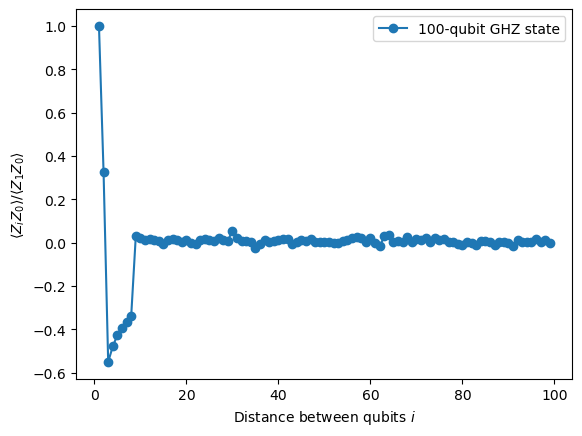

In [23]:
# data
data = list(range(1, len(operators) + 1))  # Distance between the Z operators
result = job.result()[0]
values = result.data.evs  # Expectation value at each Z operator.
values = [
    v / values[0] for v in values
]  # Normalize the expectation values to evaluate how they decay with distance.

# plotting graph
plt.plot(data, values, marker="o", label="100-qubit GHZ state")
plt.xlabel("Distance between qubits $i$")
plt.ylabel(r"$\langle Z_i Z_0 \rangle / \langle Z_1 Z_0 \rangle $")
plt.legend()
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import BaseEstimatorV2
from qiskit.circuit.library import XGate
from qiskit.circuit.library import efficient_su2
from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes.scheduling import (
    ALAPScheduleAnalysis,
    PadDynamicalDecoupling,
)
from qiskit_ibm_runtime import QiskitRuntimeService, Session, EstimatorV2


def visualize_results(results):
    plt.plot(results["cost_history"], lw=2)
    plt.xlabel("Number of function evaluations")
    plt.ylabel("Energy")
    plt.show()

In [29]:
num_spins = 10
ansatz = efficient_su2(num_qubits=num_spins, reps=2)

sservice = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, min_num_qubits=num_spins, simulator=False
)  # Replace with your actual API token  # Replace with your instance name if needed


coupling = backend.target.build_coupling_map()
reduced_coupling = coupling.reduce(list(range(num_spins)))

edge_list = reduced_coupling.graph.edge_list()
ham_list = []

for edge in edge_list:
    ham_list.append(("ZZ", edge, 0.5))
    ham_list.append(("YY", edge, 0.5))
    ham_list.append(("XX", edge, 0.5))

for qubit in reduced_coupling.physical_qubits:
    ham_list.append(("Z", [qubit], np.random.random() * 2 - 1))

hamiltonian = SparsePauliOp.from_sparse_list(ham_list, num_qubits=num_spins)

ansatz.draw("mpl", style="iqp")

InvalidAccountError: 'Unable to retrieve instances. Please check that you are using a valid API token.'